In [1]:
import importlib
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

from bssfp_reader import bSSFPArchive
from split_xk_bpt import SplitXkBPT
from process_bpt import ProcessBPT, plot_bpts

%matplotlib inline
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

We will load raw k-space from the largest ScanArchive in your chosen series. Then we will extract the BPT signals, and low-pass filter k-space to get BPT-free k-space (removing the zipper artifact from your images).

You can access the following variables (and more!):
- bssfp.xk_time: time-ordered k-space (Ncoils, Npe * Nslice, Nro)
- bssfp.xk_recon: trajectory-ordered k-space, to get images from (Ncoils, Nro, Npe, Nslice)

- split_xk_bpt.bpts: raw BPT signal(s) (1, Nsp, Nc)
- split_xk_bpt.xk_cleaned: BPT-free, coil-compressed k-space (Ncoils_comp, Nsp, Nr)

- process_bpt.bpts_lpf: filtered BPT signal(s) (Nsp, num_bpts * Nc) 
    - Can be unflattened with `_unflatten_bpts()`
    - Might need to use `force_reload=True` in `process_bpt.run()` to access this variable (it isn't cached).
- process_bpt.bpts_proc: processed BPT signals' principal components (Nsp, nrank)

In [2]:
# Path to bSSFP ScanArchive folder
inpdir = "/home/rinbha/Series1/"

# Get k-space and metadata
bssfp = bSSFPArchive(inpdir)
bssfp.get_metadata(force_reload=False)
bssfp.get_ksp(force_reload=False)

# Get BPT and BPT-free k-space
split_xk_bpt = SplitXkBPT(inp_dir=inpdir, verbose=True)
split_xk_bpt.run(force_reload=True)

# Get processed BPT signals
process_bpt = ProcessBPT(inp_dir=inpdir, verbose=True, nrank=6)
process_bpt.run(force_reload=True) # can set to false

INFO: Loading cached metadata from /home/rinbha/Series1/metadata_dict.pkl
INFO: Loading cached k-space from /home/rinbha/Series1/
INFO: Cleaned k-space and raw BPT/PT signals not found. Extracting...
INFO: Getting raw time-ordered k-space.
INFO: Getting hybrid raw k-space.
INFO: Getting coarse peaks.
INFO: Getting strongest tone.
INFO: Getting offsets.
100%|██████████| 986/986 [00:00<00:00, 1941.54it/s]
INFO: Aligning k-space.
INFO: Extracting BPT/PTs.
INFO: Cleaning k-space, still aligned.
INFO: Unaligning cleaned k-space.
INFO: Coil compressing k-space with PCA.
INFO: Saving cleaned k-space to /home/rinbha/Series1/xk_cleaned_comp.npy and raw BPT/PT signals to /home/rinbha/Series1/bpts.npy.
INFO: Processed BPT/PTs not found. Extracting them...
INFO: TR found from metadata: 821.17 ms
INFO: Loading raw BPT/PTs...
INFO: Applying median filter to BPT/PTs...
INFO: Applying low-pass filter to BPT/PTs...
INFO: Normalizing BPT/PTs...
INFO: Applying PCA to BPT/PTs...


In [4]:
bssfp.xk_recon.shape

(17, 31, 384, 92)

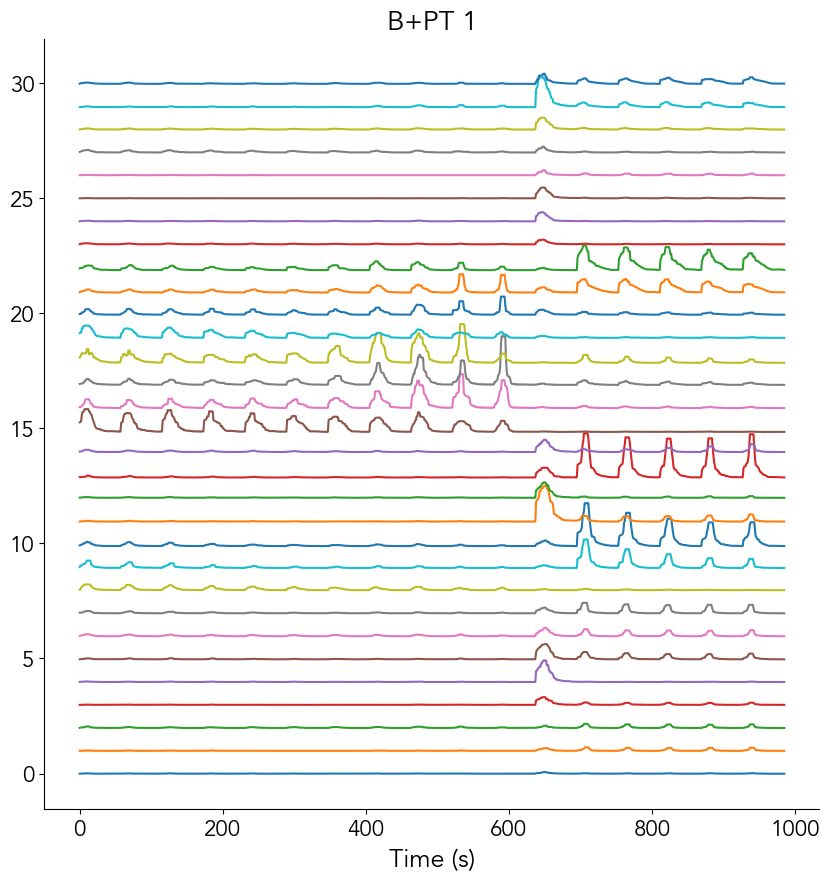

In [5]:
plot_bpts(process_bpt.bpts_lpf)